<a href="https://colab.research.google.com/github/hamidb201214-svg/Lectures/blob/main/M1_Recommender_System_v7_Students_v3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recommender Systems — step by step

**BDS Module 1 · Session 9 · AAU Business School**

This notebook follows the slides. It has two parts:

| Part | Data | What you do |
|---|---|---|
| **1 · By hand** | 5 real nomads, 6 places (a sample of the trips data) | Build **user-based**, **item-based** and **content-based** recommenders, one step at a time, and see every number |
| **2 · Real data** | 46,510 trips | Run the same steps on the Nomadlist data |

The question in Part 1 is always the same: **where should Anna go next?**

---
## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

# the colours used on the slides
BLUE, ORANGE, GREEN, GREY = "#2B5E8C", "#C85A28", "#2E7D5B", "#9AA0B5"
sns.set_theme(style="white")
pd.set_option("display.precision", 2)

---
# Part 1 · By hand: 5 real nomads, 6 places

## The data

We take a small sample of the real Nomadlist trips: **five nomads and six places**, small enough to check every number by eye.
To keep the tables readable, each nomad gets a short name (Anna = `@quintinjadam`, Ben = `@axelut`, …) and each place a short label (Bali = `ubud-bali-indonesia`).

Anna has been to Lisbon, Barcelona and Bali.

In [ ]:
df_trips = pd.read_csv("https://sds-aau.github.io/SDS-master/M1/data/trips.csv")

# five real nomads, with short names for the tables
nomads = {"@quintinjadam": "Anna", "@axelut": "Ben", "@shotsuda": "Chloe",
          "@pfitznerrene": "Dev", "@klavs": "Emma"}

# six real places, with short labels
place_names = {"lisbon-portugal": "Lisbon", "barcelona-spain": "Barcelona",
               "berlin-germany": "Berlin", "ubud-bali-indonesia": "Bali",
               "chiang-mai-thailand": "Chiang Mai", "bangkok-thailand": "Bangkok"}

sample = df_trips[df_trips["username"].isin(nomads) & df_trips["place_slug"].isin(place_names)]
sample = sample.sort_values(["username", "date_start"])
sample[["username", "place_slug", "date_start", "date_end"]]

,username,place_slug,date_start,date_end
41545,@axelut,berlin-germany,2014-04-15,2014-04-19
41543,@axelut,barcelona-spain,2015-09-26,2015-10-02
41540,@axelut,berlin-germany,2016-12-09,2016-12-13
41535,@axelut,lisbon-portugal,2017-11-22,2017-11-27
41523,@axelut,ubud-bali-indonesia,2018-06-27,2018-07-08
8593,@klavs,bangkok-thailand,2016-01-28,2016-02-04
8592,@klavs,chiang-mai-thailand,2016-02-05,2016-02-29
43978,@pfitznerrene,berlin-germany,2018-03-09,2018-03-11
43976,@pfitznerrene,lisbon-portugal,2018-05-25,NaN
4402,@quintinjadam,ubud-bali-indonesia,2018-02-06,2018-03-01


**16 stays.** Anna went to Barcelona twice and Ben to Berlin twice. We only ask *whether* someone went, not how often,
so we keep one row per (nomad, place) and switch to the short names. That leaves **14 visits**.

In [ ]:
trips = (sample[["username", "place_slug"]]
         .drop_duplicates()
         .replace({"username": nomads, "place_slug": place_names})
         .rename(columns={"place_slug": "place"})
         .reset_index(drop=True))

print(len(trips), "visits")
trips

14 visits


,username,place
0,Ben,Berlin
1,Ben,Barcelona
2,Ben,Lisbon
3,Ben,Bali
4,Emma,Bangkok
5,Emma,Chiang Mai
6,Dev,Berlin
7,Dev,Lisbon
8,Anna,Bali
9,Anna,Barcelona


**Turn the list into a table.** Rows are people, columns are places, `1` = went there.
`pd.crosstab` counts how often each (person, place) pair appears — after `drop_duplicates` every count is 1.

In [ ]:
places = ["Lisbon", "Barcelona", "Berlin", "Bali", "Chiang Mai", "Bangkok"]

matrix = pd.crosstab(trips["username"], trips["place"])[places]
matrix

place,Lisbon,Barcelona,Berlin,Bali,Chiang Mai,Bangkok
username,,,,,,
Anna,1,1,0,1,0,0
Ben,1,1,1,1,0,0
Chloe,0,0,0,1,1,1
Dev,1,0,1,0,0,0
Emma,0,0,0,0,1,1


A small helper to draw a table as a heat map. We use it for every similarity table below.

In [ ]:
def heatmap(table, color, title):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(table, annot=True, fmt=".2f", cmap=cmap, vmin=0, vmax=1,
                cbar=False, linewidths=1, linecolor="white")
    plt.title(title)
    plt.show()

---
## 1 · User-based: find the nomad most like Anna

### Step 1 — compare Anna's row with Ben's row

**Cosine similarity** = shared places ÷ (length of Anna × length of Ben).
`1` means identical taste, `0` means nothing in common.

In [ ]:
anna = matrix.loc["Anna"].values
ben  = matrix.loc["Ben"].values

shared = np.dot(anna, ben)              # places they both visited
length_anna = np.linalg.norm(anna)      # √3
length_ben  = np.linalg.norm(ben)       # √4

print("shared places:", shared)
print("cosine:", round(shared / (length_anna * length_ben), 2))

shared places: 3
cosine: 0.87


In [ ]:
anna = matrix.loc[["Anna"]]    # double brackets: a table with 1 row (the library needs 2-D input)
ben  = matrix.loc[["Ben"]]

cos = cosine_similarity(anna, ben)     # returns a 1 × 1 table
print("cosine:", round(cos[0, 0], 2))  # 0.87

cosine: 0.87


### Step 2 — the similarity between every pair of nomads

`cosine_similarity` does Step 1 for every pair at once. Read **Anna's row**.

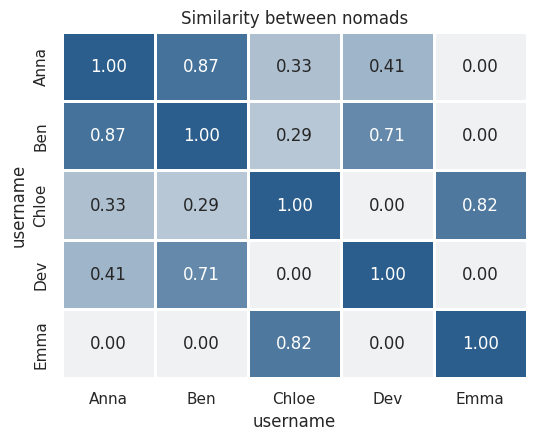

In [ ]:
user_sim = pd.DataFrame(cosine_similarity(matrix), index=matrix.index, columns=matrix.index)

heatmap(user_sim, BLUE, "Similarity between nomads")

In [ ]:
# Anna's neighbours, closest first (drop Anna herself)
user_sim["Anna"].drop("Anna").sort_values(ascending=False)

,Anna
username,
Ben,0.87
Dev,0.41
Chloe,0.33
Emma,0.00


### Step 2b — the taste map

`TruncatedSVD` squeezes the 6 place-columns into 2 "taste" columns, so we can draw every nomad as an arrow.
**Small angle between arrows = similar taste.** In Part 2 we squeeze 961 columns into 5 — same idea, but we can't draw it.

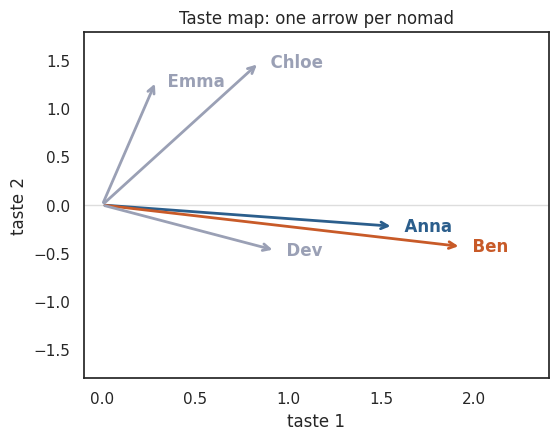

In [ ]:
svd = TruncatedSVD(n_components=2, random_state=42)
taste = svd.fit_transform(matrix)

plt.figure(figsize=(6, 4.5))
for name, (x, y) in zip(matrix.index, taste):
    color = {"Anna": BLUE, "Ben": ORANGE}.get(name, GREY)
    plt.annotate("", xy=(x, y), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=color, lw=2))
    plt.text(x, y, "  " + name, color=color, fontweight="bold", va="center")
plt.axhline(0, color="#DDD", lw=1)
plt.xlim(-0.1, 2.4); plt.ylim(-1.8, 1.8)
plt.xlabel("taste 1"); plt.ylabel("taste 2")
plt.title("Taste map: one arrow per nomad")
plt.show()

### Step 3 — recommend what Ben did that Anna has not

The recommendation is a **set difference**: Ben's places minus Anna's places.

In [ ]:
def places_of(user):
    return list(matrix.columns[matrix.loc[user] > 0])

mine   = places_of("Anna")
theirs = places_of("Ben")

[p for p in theirs if p not in mine]

['Berlin']

In [ ]:
theirs

['Lisbon', 'Barcelona', 'Berlin', 'Bali']

In [ ]:
mine

['Lisbon', 'Barcelona', 'Bali']

> **User-based in four moves:** matrix → similarity → nearest nomad → their places minus yours.

---
## 2 · Item-based: find places most like Anna's places

### Step 1 — flip the matrix

`.T` (transpose) makes places the rows. Two places are similar when **the same people** went to both.

In [ ]:
matrix.T

username,Anna,Ben,Chloe,Dev,Emma
place,,,,,
Lisbon,1,1,0,1,0
Barcelona,1,1,0,0,0
Berlin,0,1,0,1,0
Bali,1,1,1,0,0
Chiang Mai,0,0,1,0,1
Bangkok,0,0,1,0,1


### Step 2 — the similarity between every pair of places

Same function, flipped table. Look for the **blocks**: Europe top-left, Asia bottom-right.

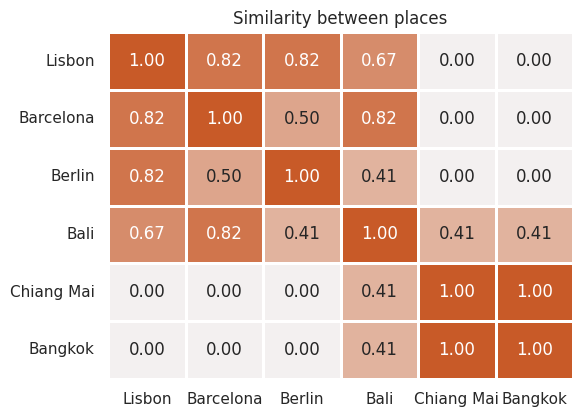

In [ ]:
place_sim = pd.DataFrame(cosine_similarity(matrix.T), index=places, columns=places)

heatmap(place_sim, ORANGE, "Similarity between places")

### Step 3 — score every place Anna has not visited

For each new place, **add up** its similarity to the places Anna already chose. Highest score wins.
(The slide shows 1.73 for Berlin because it adds the rounded numbers; Python prints 1.72.)

In [ ]:
mine

['Lisbon', 'Barcelona', 'Bali']

In [ ]:
visited     = places_of("Anna")
not_visited = [p for p in places if p not in visited]

table = place_sim.loc[not_visited, visited]
table["score"] = table.sum(axis=1)
table.sort_values("score", ascending=False)

,Lisbon,Barcelona,Bali,score
Berlin,0.82,0.5,0.41,1.72
Chiang Mai,0.00,0.0,0.41,0.41
Bangkok,0.00,0.0,0.41,0.41


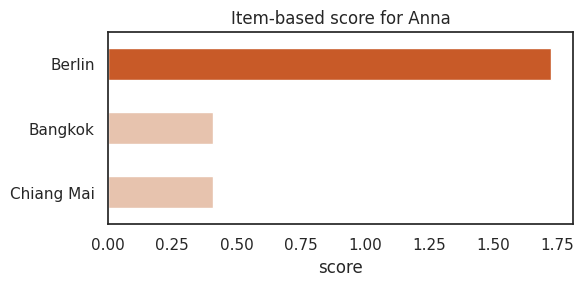

In [ ]:
scores = table["score"].sort_values()
scores.plot.barh(color=[ORANGE if p == scores.idxmax() else "#E7C3AE" for p in scores.index], figsize=(6, 2.5))
plt.title("Item-based score for Anna"); plt.xlabel("score"); plt.show()

> **Item-based in three moves:** transpose → place–place similarity → score what is new to you.

---
## 3 · Content-based: describe each place, match Anna's profile

No trips needed here. We describe every place with two scores between 0 and 1.
**Da Nang** is not in our 6-place sample, so in this table nobody has been there — treat it as a brand-new place.

In [ ]:
features = pd.DataFrame({
    "beach":     [0.60, 0.90, 0.05, 1.00, 0.10, 0.30, 0.85],
    "nightlife": [0.80, 0.95, 1.00, 0.40, 0.20, 0.90, 0.55],
}, index=places + ["Da Nang"])

features

,beach,nightlife
Lisbon,0.60,0.80
Barcelona,0.90,0.95
Berlin,0.05,1.00
Bali,1.00,0.40
Chiang Mai,0.10,0.20
Bangkok,0.30,0.90
Da Nang,0.85,0.55


### Step 1 — put the places on a map

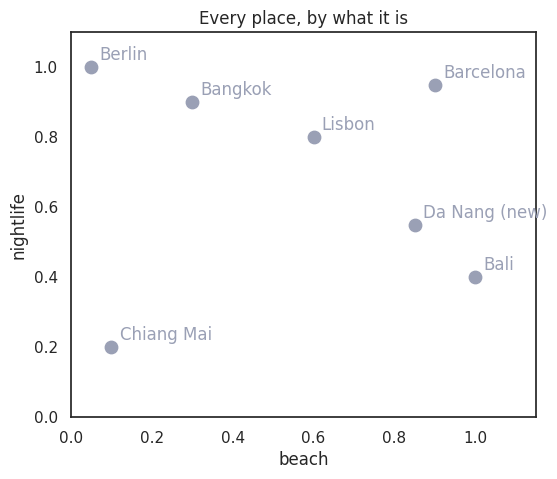

In [ ]:
def place_map(highlight=(), title=""):
    plt.figure(figsize=(6, 5))
    for name, (x, y) in features.iterrows():
        color = GREEN if name in highlight else GREY
        plt.scatter(x, y, s=80, color=color, zorder=3)
        plt.text(x + 0.02, y + 0.02, name + (" (new)" if name == "Da Nang" else ""), color=color)
    plt.xlim(0, 1.15); plt.ylim(0, 1.1)
    plt.xlabel("beach"); plt.ylabel("nightlife"); plt.title(title)

place_map(title="Every place, by what it is")
plt.show()

### Step 2 — Anna's profile = the average of her places

The same move as a k-means centroid in Session 7.

In [ ]:
profile = features.loc[visited].mean()
profile

,0
beach,0.83
nightlife,0.72


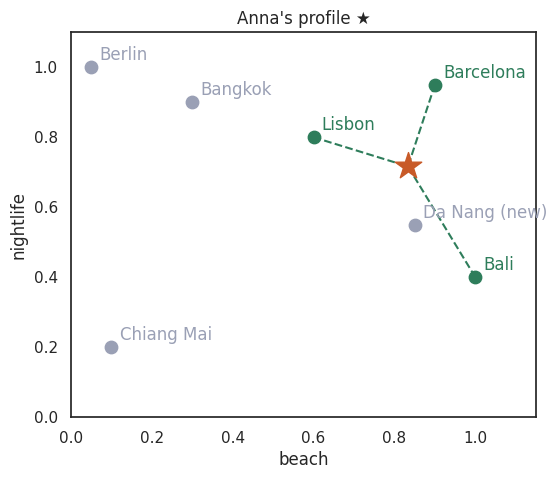

In [ ]:
place_map(highlight=visited, title="Anna's profile ★")
for p in visited:
    plt.plot([features.loc[p, "beach"], profile["beach"]],
             [features.loc[p, "nightlife"], profile["nightlife"]], "--", color=GREEN)
plt.scatter(*profile, marker="*", s=400, color=ORANGE, zorder=4)
plt.show()

### Step 3 — recommend the place nearest to ★

Features are dense and on the same scale, so we use **Euclidean distance** (the 4 steps from Session 7).

In [ ]:
candidates = not_visited + ["Da Nang"]

distance = np.sqrt(((features.loc[candidates] - profile) ** 2).sum(axis=1))
distance.sort_values()

,0
Da Nang,0.17
Bangkok,0.56
Berlin,0.83
Chiang Mai,0.90


Content-based recommends **Da Nang** — a place with zero trips in our sample. User-based and item-based can never see it,
because its column in the matrix would be empty. That is the **cold-start** problem, and why hybrids exist.

| | User-based | Item-based | Content-based |
|---|---|---|---|
| **Recommends for Anna** | Berlin | Berlin | Da Nang |
| **Evidence** | rows of the matrix | columns of the matrix | features of each place |
| **Breaks for** | new users | new places | only more of the same |

---
## 🛠 Exercise 1 — Your turn: recommend a place for Dev

Dev has been to **Lisbon** and **Berlin**. Re-use the code above — only the name changes.
Do all three methods agree this time?

**(a) User-based.** Who is Dev's nearest neighbour? Which of their places has Dev not visited?

**(b) Item-based.** Score every place Dev has not visited.

**(c) Content-based.** Build Dev's profile and find the nearest place he has not visited.

---
# Part 2 · Real data: 46,510 trips

Exactly the same steps. Three differences:

1. The table is big: **2,871 nomads × 961 places**, and **99% of it is zeros**.
2. We add the SVD step for real (961 columns → 5) before measuring similarity.
3. We must **check the evidence** behind a recommendation before we believe it.

In [ ]:
df_trips = pd.read_csv("https://sds-aau.github.io/SDS-master/M1/data/trips.csv")
print(df_trips.shape)
df_trips[["username", "place_slug", "country_code"]].head()

(46510, 11)


,username,place_slug,country_code
0,@lewellenmichael,mexico,MX
1,@lewellenmichael,mexico-city-mexico,MX
2,@lewellenmichael,cancun-mexico,MX
3,@lewellenmichael,amman-jordan,JO
4,@waylandchin,china,CN


### Clean first

Some rows have no `place_slug`. If we leave them in, "missing" becomes a place that can be recommended.

In [ ]:
print("rows with no place:", df_trips["place_slug"].isna().sum())
df_trips = df_trips.dropna(subset=["place_slug"])

rows with no place: 37


### Step 1 — the matrix

Same `crosstab` as Part 1. Keeping the names as row and column labels means we never need to translate IDs back.
(The notebook from last year used `LabelEncoder` for this; `crosstab` gives the same matrix.)

In [ ]:
matrix_real = pd.crosstab(df_trips["username"], df_trips["place_slug"])
print("shape:", matrix_real.shape)
print("filled in:", round((matrix_real > 0).values.mean() * 100, 2), "%")

shape: (2869, 960)
filled in: 1.04 %


### Step 2 — reduce: 961 columns → 5

This is the taste map from Part 1, with 5 tastes instead of 2.

In [ ]:
svd = TruncatedSVD(n_components=5, random_state=42)
user_taste = svd.fit_transform(matrix_real)
print(user_taste.shape)
print("variance kept:", round(svd.explained_variance_ratio_.sum() * 100, 1), "%")

(2869, 5)
variance kept: 38.4 %


### Step 3 — user-based recommendations

One function that does the four moves from Part 1.

In [ ]:
user_sim_real = pd.DataFrame(cosine_similarity(user_taste),
                             index=matrix_real.index, columns=matrix_real.index)

def recommend_user_based(user, n=10):
    nearest = user_sim_real[user].drop(user).idxmax()
    mine    = set(df_trips.loc[df_trips["username"] == user, "place_slug"])
    theirs  = df_trips.loc[df_trips["username"] == nearest, "place_slug"].unique()
    print("nearest nomad:", nearest)
    return [p for p in theirs if p not in mine][:n]

recommend_user_based("@cw")

nearest nomad: @travpreneur


['pune-india',
 'manchester-united-kingdom',
 'san-diego-ca-united-states',
 'san-jose-ca-united-states',
 'amsterdam-netherlands',
 'birmingham-united-kingdom',
 'mumbai-india',
 'victoria-seychelles',
 'johannesburg-south-africa',
 'delhi-india']

### Item-based: places similar to Ubud

Transpose, reduce, compare — and **show how many people visited each result**.

In [ ]:
place_taste = TruncatedSVD(n_components=5, random_state=42).fit_transform(matrix_real.T)
place_sim_real = pd.DataFrame(cosine_similarity(place_taste),
                              index=matrix_real.columns, columns=matrix_real.columns)

visits = df_trips["place_slug"].value_counts()

def similar_places(place, n=10):
    top = place_sim_real[place].drop(place).sort_values(ascending=False).head(n)
    return pd.DataFrame({"similarity": top, "visits": visits[top.index]})

similar_places("ubud-bali-indonesia")

,similarity,visits
place_slug,,
darwin-australia,1.00,9
ko-pha-ngan-thailand,1.00,144
phnom-penh-cambodia,0.99,125
siem-reap-cambodia,0.99,158
gurgaon-india,0.99,2
ho-chi-minh-city-vietnam,0.99,379
riga-latvia,0.99,50
kuala-lumpur-malaysia,0.99,556
yogyakarta-indonesia,0.99,24


**Read it like a sceptic.** Look at the `visits` column. A place with a handful of visitors can look very similar
to Ubud by accident. Its direction is decided by almost nobody.

The fix: only recommend places with enough evidence.

In [ ]:
def similar_places_checked(place, n=10, min_visits=50):
    table = similar_places(place, n=len(visits))
    return table[table["visits"] >= min_visits].head(n)

similar_places_checked("ubud-bali-indonesia")

,similarity,visits
place_slug,,
ko-pha-ngan-thailand,1.00,144
phnom-penh-cambodia,0.99,125
siem-reap-cambodia,0.99,158
ho-chi-minh-city-vietnam,0.99,379
riga-latvia,0.99,50
kuala-lumpur-malaysia,0.99,556
chiang-mai-thailand,0.99,913
taipei-taiwan,0.99,264
ko-lanta-thailand,0.99,170


---
## 🛠 Exercise 2 — Countries instead of places

Build an **item-based** recommender where the items are **countries** (`country_code`).
Which countries are most similar to Denmark (`"DK"`)? Check the evidence.

The three steps do not change — only the column you put into `crosstab`.

In [ ]:
# Step 1 — matrix: nomads × countries

# Step 2 — reduce, with countries as the rows

# Step 3 — similarity, then read Denmark's row



,similarity,visits
country_code,,
CH,0.99,409
CZ,0.97,325
NO,0.97,307
EE,0.96,127
ZA,0.95,252
VE,0.95,7
IE,0.94,344
IT,0.93,1196
PA,0.93,119


## 🛠 Exercise 3 — Change one number

Go back to Part 2, Step 2 and try `n_components=20` and `n_components=50`.
Do the places similar to Ubud change? Which setting would you defend to a manager, and why?

n_components=5: ['ko-pha-ngan-thailand', 'phnom-penh-cambodia', 'siem-reap-cambodia', 'ho-chi-minh-city-vietnam', 'riga-latvia']
n_components=20: ['siem-reap-cambodia', 'phnom-penh-cambodia', 'phuket-thailand', 'da-nang-vietnam', 'canggu-bali-indonesia']
n_components=50: ['canggu-bali-indonesia', 'jakarta-indonesia', 'indonesia', 'krabi-thailand', 'singapore-singapore']


---
## What to take away

1. **Every recommender here is the same three steps:** build the matrix → (reduce) → measure similarity.
2. **User-based** compares rows, **item-based** compares columns (one `.T`), **content-based** compares descriptions.
3. **Always check the evidence** (number of visits) before you trust a recommendation.
4. **Collaborative filtering cannot see new places.** Content-based can — which is why real systems mix both.